In [97]:
# Libraries
import sys
sys.path.append("..")
from src.utils import section

import matplotlib.pyplot as plt
import seaborn as sns

In [98]:
from src.data_load import data_loader

# Load data
df = data_loader("../data/raw/ecommerce_return_classification.csv")
df.head()

,cart_value_usd,past_return_rate,size_bracketing_flag,delivery_days_taken,discount_pct_applied,product_category,fit_review_sentiment,newsletter_subscriber,browser_used,checkout_device,packaging_color,loyalty_card_color,return_risk_label
0,172.17,0.233,1,11,10,Footwear,True-to-Size,1,Safari,Android-App,Kraft-Brown,Platinum,1
1,213.55,0.235,1,6,40,Accessories,True-to-Size,0,Firefox,Android-App,Branded-Teal,Silver,0
2,371.70,0.461,1,11,40,Formal-Eveningwear,True-to-Size,0,Firefox,iOS-App,Kraft-Brown,Gold,1
3,317.18,0.080,0,1,20,Footwear,Inconsistent-Sizing,0,Firefox,iOS-App,Kraft-Brown,Gold,1
4,152.68,0.133,0,3,40,Accessories,True-to-Size,0,Edge,iOS-App,Branded-Teal,Silver,0


In [99]:
# Basic data exploration

# Shape of data
section("shape of data", 40)
print(f"Columns:             {df.shape[1]:,}\nRows:                {df.shape[0]:,}")

# Null values count
section("Null values", 40)
print(df.isnull().sum())

# Duplicate values
section("Duplicates", 40)
print(f"Number of duplicates:        {df.duplicated().sum()}")

# Basic info
section("Basic columns info", 40)
display(df.info())

# Statistical info
section("Statistical info", 40)
display(df.describe())

                                        
SHAPE OF DATA:
Columns:             13
Rows:                2,993
                                        
NULL VALUES:
cart_value_usd           0
past_return_rate         0
size_bracketing_flag     0
delivery_days_taken      0
discount_pct_applied     0
product_category         0
fit_review_sentiment     0
newsletter_subscriber    0
browser_used             0
checkout_device          0
packaging_color          0
loyalty_card_color       0
return_risk_label        0
dtype: int64
                                        
DUPLICATES:
Number of duplicates:        0
                                        
BASIC COLUMNS INFO:
<class 'pandas.DataFrame'>
RangeIndex: 2993 entries, 0 to 2992
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   cart_value_usd         2993 non-null   float64
 1   past_return_rate       2993 non-null   float64
 2   size_bracketing_flag 

None

                                        
STATISTICAL INFO:


,cart_value_usd,past_return_rate,size_bracketing_flag,delivery_days_taken,discount_pct_applied,newsletter_subscriber,return_risk_label
count,2993.000000,2993.000000,2993.000000,2993.000000,2993.000000,2993.000000,2993.000000
mean,239.750301,0.284024,0.354160,5.974273,23.879051,0.503508,0.645506
std,121.394772,0.159998,0.478338,3.188330,17.263143,0.500071,0.478440
min,25.010000,0.005000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,135.560000,0.157000,0.000000,3.000000,10.000000,0.000000,0.000000
50%,238.740000,0.265000,0.000000,6.000000,20.000000,1.000000,1.000000
75%,343.920000,0.386000,1.000000,9.000000,40.000000,1.000000,1.000000
max,449.860000,0.884000,1.000000,11.000000,50.000000,1.000000,1.000000


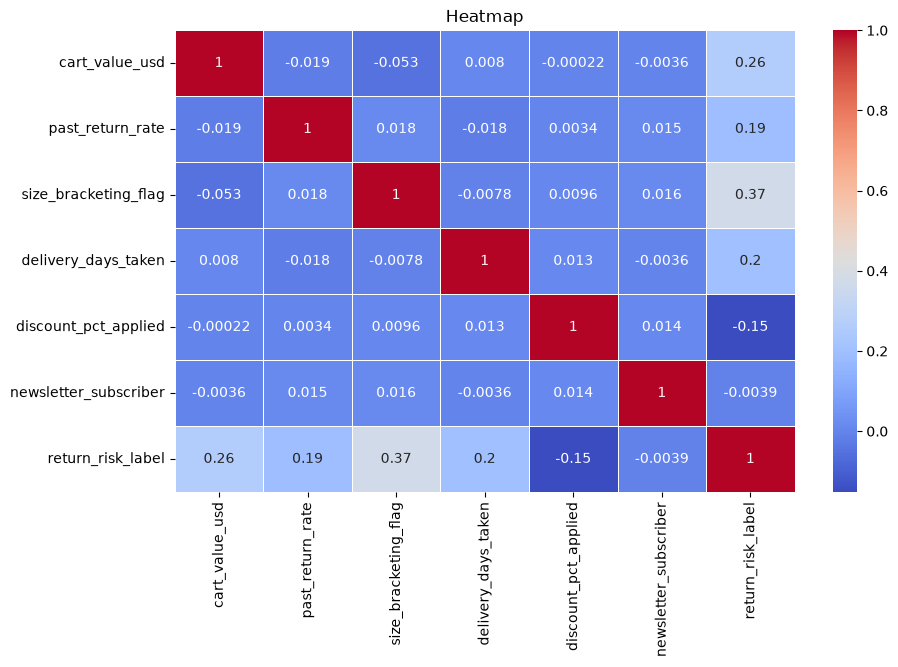

In [100]:
# Heatmap 
plt.figure(figsize=(10,6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    linecolor='white',
    linewidths=0.5
)
plt.title("Heatmap")
plt.savefig(f"../figures/corelation/corelation-matrix.png", dpi=600, bbox_inches='tight')
plt.show()

                                                                                     
OUTLIERS DETECTION:


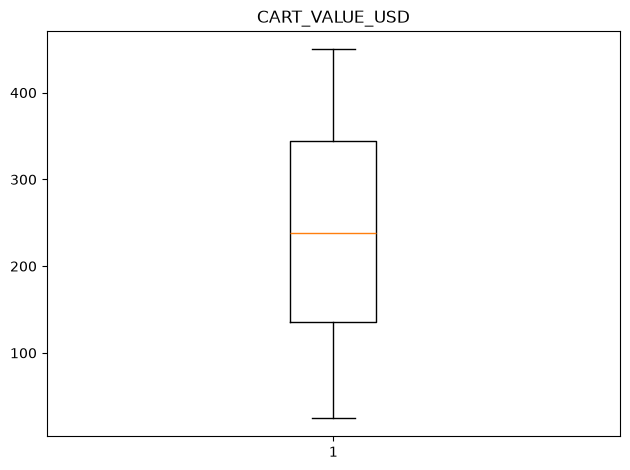

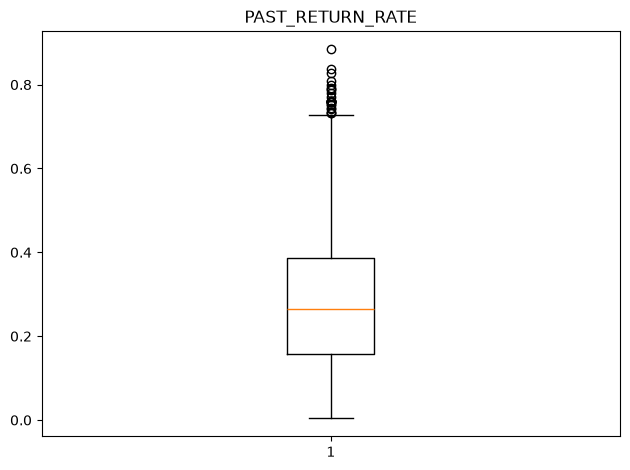

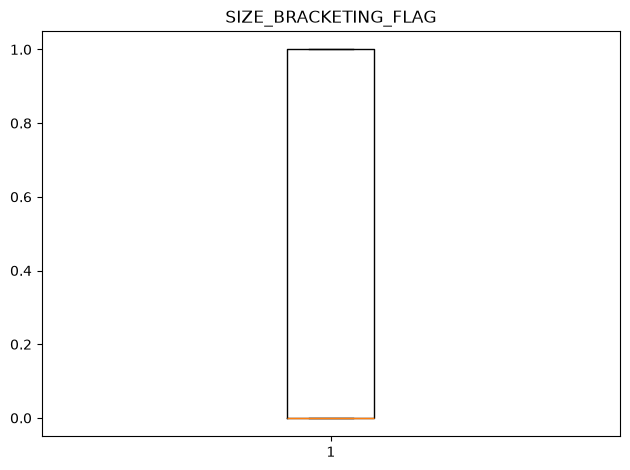

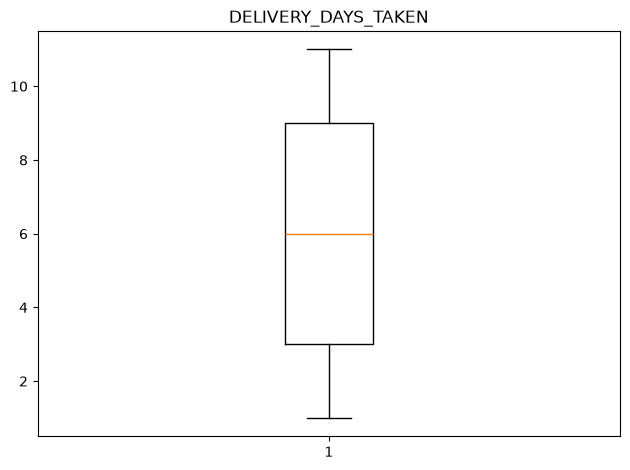

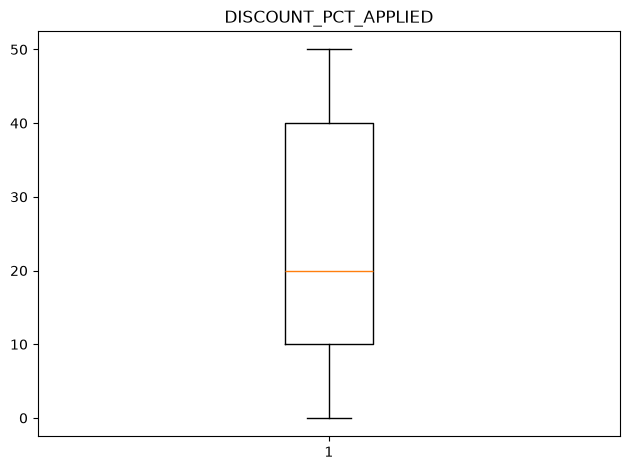

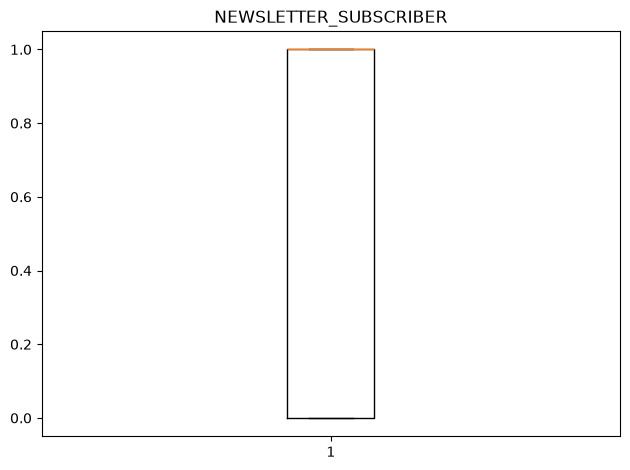

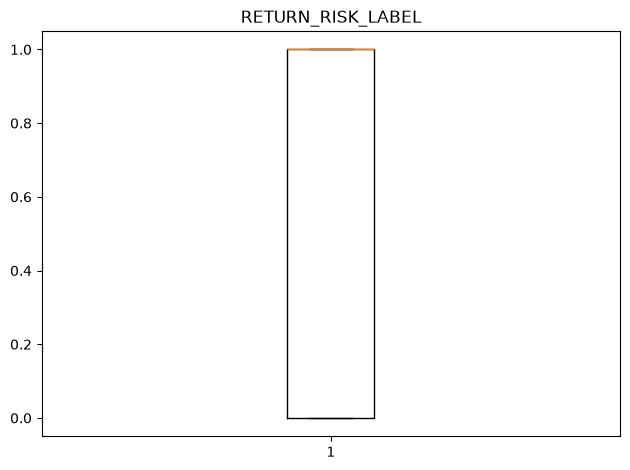

In [101]:
# Outliers detection

num_cols = df.select_dtypes(include=['int', 'float']).columns.tolist()

section("outliers detection", 85)
for col in num_cols:
    plt.boxplot(
        df[col]
    )
    plt.title(col.upper())
    plt.tight_layout()
    plt.savefig(f'../figures/outliers/{col}.png', dpi=600, bbox_inches='tight')
    plt.show()